In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

print("Import xong!")


Import xong!


In [3]:
import glob

csv_files = glob.glob('*.csv')
print(f"Tìm thấy {len(csv_files)} file:")
for f in csv_files:
    print(f)

df = pd.concat([pd.read_csv(f, encoding='utf-8', low_memory=False) 
                for f in csv_files], ignore_index=True)

print(f"\nTổng số dòng: {df.shape[0]:,}")
print(f"Số cột: {df.shape[1]}")


Tìm thấy 8 file:
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv

Tổng số dòng: 2,830,743
Số cột: 79


In [4]:
# Xóa khoảng trắng tên cột
df.columns = df.columns.str.strip()

# Thay inf và NaN bằng median
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Xóa cột zero-variance
before = df.shape[1]
df = df.loc[:, df.nunique() > 1]
print(f"Xóa {before - df.shape[1]} cột zero-variance")

# Xóa dòng duplicate
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Xóa {before - df.shape[0]:,} dòng duplicate")

print(f"\nSau cleaning: {df.shape[0]:,} dòng, {df.shape[1]} cột")


Xóa 8 cột zero-variance
Xóa 308,381 dòng duplicate

Sau cleaning: 2,522,362 dòng, 71 cột


In [5]:
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

print(f"Memory sau tối ưu: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Memory sau tối ưu: 883.4 MB


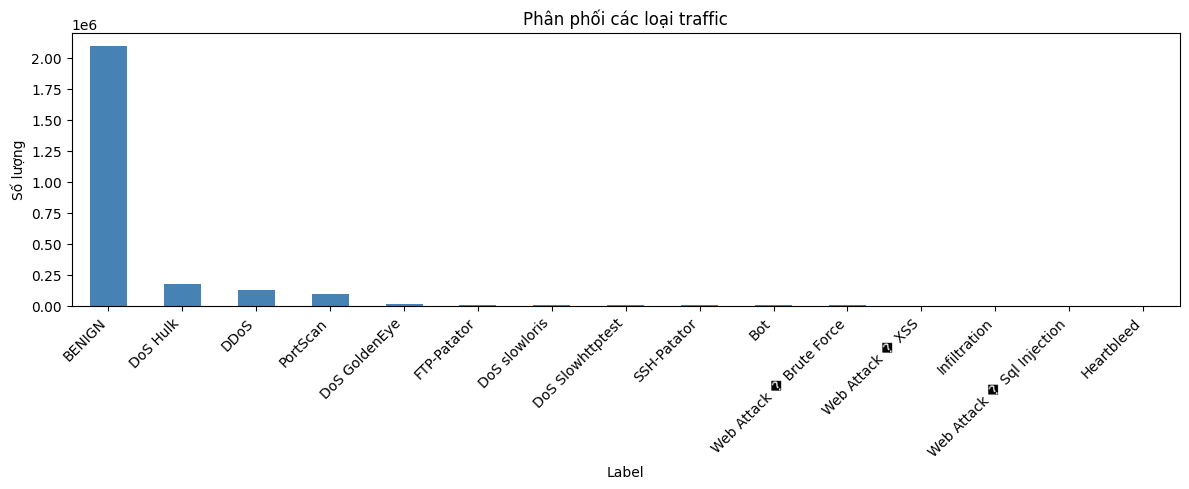


Phân phối nhãn:
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(12, 5))
df['Label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Phân phối các loại traffic')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png')
plt.show()

print("\nPhân phối nhãn:")
print(df['Label'].value_counts())


In [7]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packe

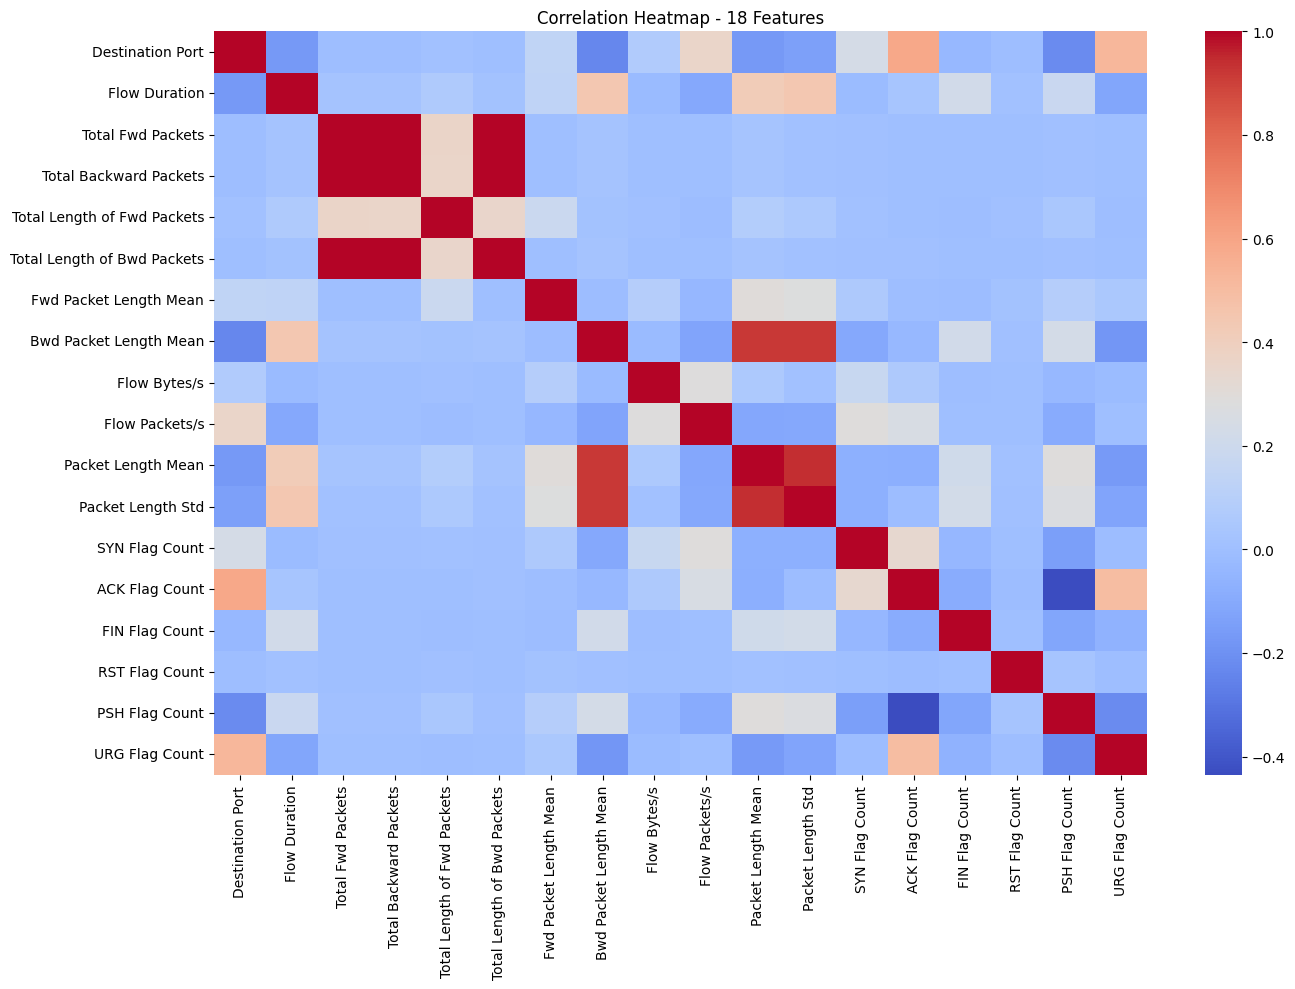

Heatmap xong!


In [8]:
selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count',
    'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count',
    'PSH Flag Count', 'URG Flag Count'
]

plt.figure(figsize=(14, 10))
sns.heatmap(df[selected_features].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap - 18 Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("Heatmap xong!")


In [9]:
# Encode label
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
print("Classes:", list(le.classes_))
print("Encoded:", list(range(len(le.classes_))))

# Chọn 18 feature (tên đúng với dataset)
selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count',
    'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count',
    'PSH Flag Count', 'URG Flag Count'
]

X = df[selected_features]
y = df['Label']

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")


Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Encoded: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

X_train: (2017889, 18)
X_test:  (504473, 18)


In [10]:
# Fix NaN
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

print("NaN sau fix:", np.isnan(X_train).sum())

# SMOTE - dùng 'not majority' thay vì float
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# UnderSampler
rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

print("\nPhân phối sau balance:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(le.inverse_transform(unique), counts):
    print(f"  {u}: {c:,}")

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("\nSẵn sàng train model!")


NaN sau fix: 0

Phân phối sau balance:
  BENIGN: 1,677,187
  Bot: 1,677,187
  DDoS: 1,677,187
  DoS GoldenEye: 1,677,187
  DoS Hulk: 1,677,187
  DoS Slowhttptest: 1,677,187
  DoS slowloris: 1,677,187
  FTP-Patator: 1,677,187
  Heartbleed: 1,677,187
  Infiltration: 1,677,187
  PortScan: 1,677,187
  SSH-Patator: 1,677,187
  Web Attack � Brute Force: 1,677,187
  Web Attack � Sql Injection: 1,677,187
  Web Attack � XSS: 1,677,187

X_train: (25157805, 18)
X_test:  (504473, 18)

Sẵn sàng train model!


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import time

# Lấy mẫu nhỏ để train nhanh hơn
from sklearn.utils import resample
sample_size = 200000
idx = resample(range(len(X_train)), n_samples=sample_size, random_state=42)
X_sample = X_train[idx]
y_sample = y_train[idx]

print(f"Train trên {sample_size:,} mẫu")

# Định nghĩa các model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         GaussianNB(),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    start = time.time()
    model.fit(X_sample, y_sample)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, 
                                   target_names=le.classes_, 
                                   output_dict=True)
    results[name] = report
    print(f"Thời gian: {elapsed:.1f}s")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Train trên 200,000 mẫu

--- Training Logistic Regression ---
Thời gian: 73.3s
                            precision    recall  f1-score   support

                    BENIGN       0.93      0.53      0.67    419297
                       Bot       0.00      0.64      0.01       391
                      DDoS       0.01      0.00      0.00     25603
             DoS GoldenEye       0.00      0.00      0.00      2057
                  DoS Hulk       0.19      0.82      0.31     34570
          DoS Slowhttptest       0.00      0.01      0.00      1046
             DoS slowloris       0.00      0.00      0.00      1077
               FTP-Patator       0.00      0.00      0.00      1187
                Heartbleed       0.00      1.00      0.01         2
              Infiltration       0.00      0.29      0.00         7
                  PortScan       0.31      0.89      0.45     18164
               SSH-Patator       0.00      0.00      0.00       644
  Web Attack � Brute Force       0.00

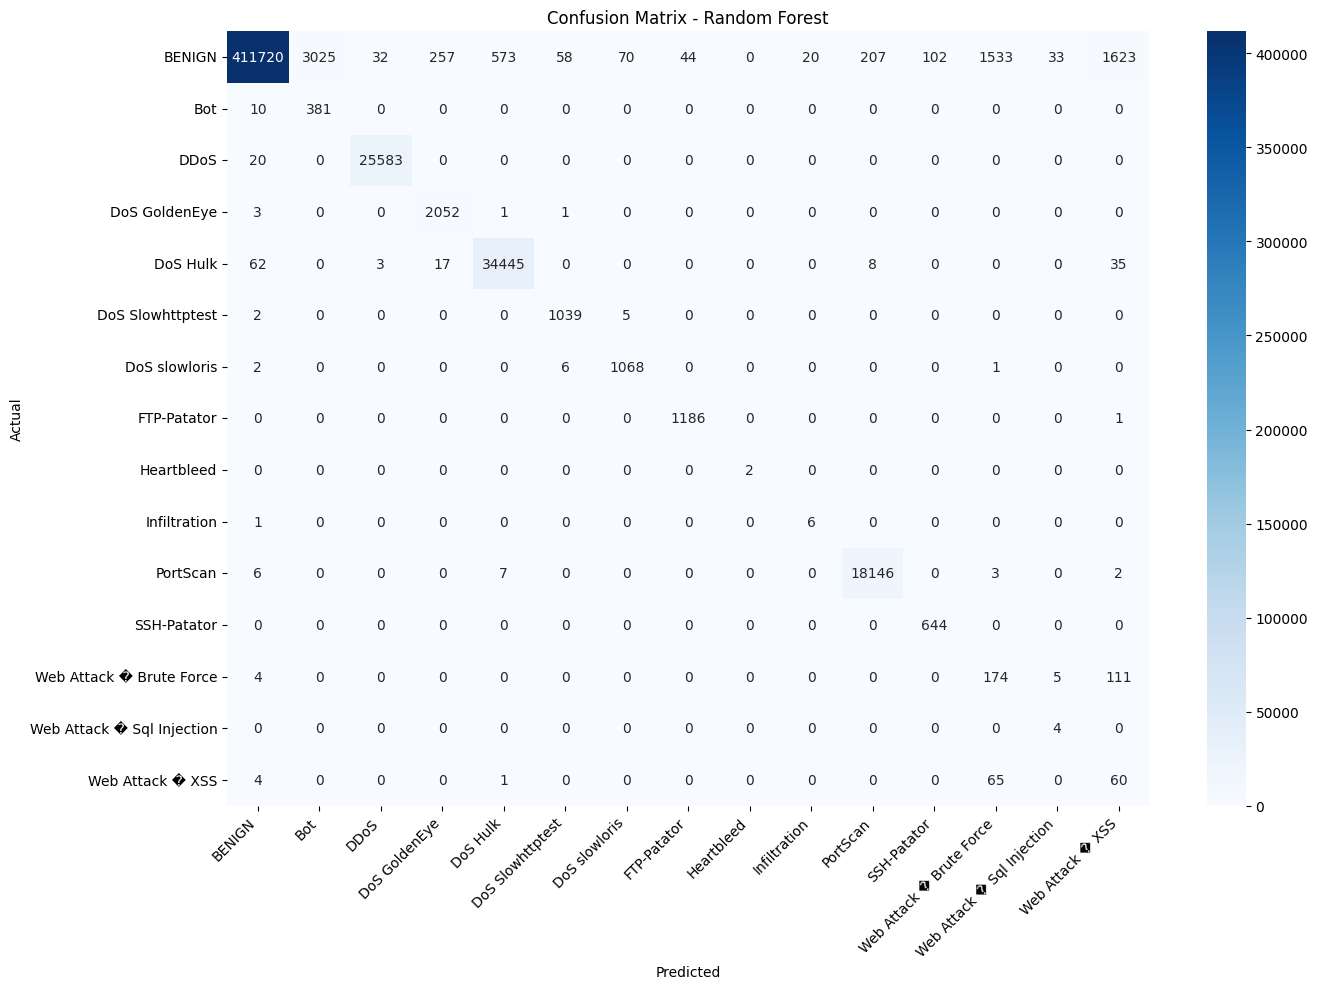

Confusion Matrix xong!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict lại bằng Random Forest
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png')
plt.show()
print("Confusion Matrix xong!")


In [13]:
# Bảng so sánh
summary = []
for name, report in results.items():
    summary.append({
        'Model': name,
        'Accuracy': f"{report['accuracy']:.4f}",
        'Precision': f"{report['weighted avg']['precision']:.4f}",
        'Recall': f"{report['weighted avg']['recall']:.4f}",
        'F1-score': f"{report['weighted avg']['f1-score']:.4f}",
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


              Model Accuracy Precision Recall F1-score
Logistic Regression   0.5289    0.7983 0.5289   0.5988
        Naive Bayes   0.1006    0.8919 0.1006   0.1290
                KNN   0.7718    0.9298 0.7718   0.8296
      Random Forest   0.9842    0.9957 0.9842   0.9894


In [14]:
import joblib
import datetime

# Lưu model
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Đã lưu model!")

# Hàm detect real-time
def detect_intrusion(flow_data):
    flow_df = pd.DataFrame([flow_data], columns=selected_features)
    flow_scaled = scalerzx.transform(flow_df)
    flow_scaled = np.nan_to_num(flow_scaled, nan=0.0)
    
    prediction = rf_model.predict(flow_scaled)[0]
    label = le.inverse_transform([prediction])[0]
    
    timestamp = datetime.datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
    
    if label != 'BENIGN':
        alert = f"[{timestamp}] [ALERT] Suspicious traffic detected: {label}. Destination Port: {int(flow_data[0])}."
        print(alert)
        with open('alerts.log', 'a') as f:
            f.write(alert + '\n')
    else:
        print(f"[{timestamp}] [INFO] Traffic is BENIGN.")
    
    return label

# Test với 5 mẫu từ X_test
print("\n--- Kiểm tra 5 mẫu ---")
X_test_df = pd.DataFrame(X_test[:5], columns=selected_features) if hasattr(X_test, '__len__') else X_test[:5]

for i in range(5):
    sample = scaler.inverse_transform([X_test[i]])[0]
    detect_intrusion(sample)


NameError: name 'scaler' is not defined

In [ ]:
import joblib
import datetime

from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Now you can use it, for example:
# X_scaled = scaler.fit_transform(X)

# Lưu model
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Đã lưu model!")

# Hàm detect real-time
def detect_intrusion(flow_data):
    flow_df = pd.DataFrame([flow_data], columns=selected_features)
    flow_scaled = scaler.transform(flow_df)
    flow_scaled = np.nan_to_num(flow_scaled, nan=0.0)
    
    prediction = rf_model.predict(flow_scaled)[0]
    label = le.inverse_transform([prediction])[0]
    
    timestamp = datetime.datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
    
    if label != 'BENIGN':
        alert = f"[{timestamp}] [ALERT] Suspicious traffic detected: {label}. Destination Port: {int(flow_data[0])}."
        print(alert)
        with open('alerts.log', 'a') as f:
            f.write(alert + '\n')
    else:
        print(f"[{timestamp}] [INFO] Traffic is BENIGN.")
    
    return label

# Test với 5 mẫu từ X_test
print("\n--- Kiểm tra 5 mẫu ---")
X_test_df = pd.DataFrame(X_test[:5], columns=selected_features) if hasattr(X_test, '__len__') else X_test[:5]

for i in range(5):
    sample = scaler.inverse_transform([X_test[i]])[0]
    detect_intrusion(sample)
